#  Netflix Recommendation System



## The 5 steps of this task

| Step | What we do | Tool |
|------|-----------|------|
 Extract the useful content features (genre, director, country ...) | `pandas` |
 Clean and prepare the text | `re` (regex) |
 Turn text into numbers and calculate similarity | `scikit-learn` |
 Generate recommendations for selected titles | our own function |
 Evaluate how good the recommendations are | metrics + charts |




 # First we import the libraries we need.

In [2]:
import re                                   # for cleaning text
import numpy as np                          # for numbers and arrays
import pandas as pd                         # for tables (DataFrames)
import matplotlib.pyplot as plt             # for charts
import seaborn as sns                       # for nicer charts
from difflib import get_close_matches       # to suggest titles if the user makes a typo

from sklearn.feature_extraction.text import TfidfVectorizer   # text -> numbers
from sklearn.metrics.pairwise import cosine_similarity        # how similar are two rows?

import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

Now we load the dataset and take a first look.

In [3]:
df = pd.read_csv("Dataset.csv")
print("Rows, Columns:", df.shape)
df.head()

Rows, Columns: (8790, 10)


,oi,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   oi            8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


### Quick health check

Before using any data, we check for problems: empty cells, duplicates and fake "empty" values.

In [5]:
print("Real empty (NaN) cells      :", df.isnull().sum().sum())
print("Fully duplicated rows       :", df.duplicated().sum())
print("Titles that appear twice    :", df["title"].duplicated().sum())
print()
print("Cells that say 'Not Given' (this is how missing info is stored):")
print((df == "Not Given").sum()[lambda s: s > 0])

Real empty (NaN) cells      : 0
Fully duplicated rows       : 0
Titles that appear twice    : 3

Cells that say 'Not Given' (this is how missing info is stored):
director    2588
country      287
dtype: int64


In [6]:
features = ["title", "type", "director", "country", "rating", "listed_in"]
data = df[features].copy()

# 'Not Given' means "unknown" -> make it empty so it is not treated as a real word
data = data.replace("Not Given", "")

# A lowercase copy of the title, used for searching ("stranger things" = "Stranger Things")
data["title_key"] = data["title"].str.lower()

# Remove repeated rows: same title AND same type.
# (A few names exist as both a Movie and a TV Show, like 'Death Note'. We keep both.)
data = data.drop_duplicates(subset=["title_key", "type"]).reset_index(drop=True)

print("Titles we will work with:", len(data))
data.head()

Titles we will work with: 8784


,title,type,director,country,rating,listed_in,title_key
0,Dick Johnson Is Dead,Movie,Kirsten Johnson,United States,PG-13,Documentaries,dick johnson is dead
1,Ganglands,TV Show,Julien Leclercq,France,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",ganglands
2,Midnight Mass,TV Show,Mike Flanagan,United States,TV-MA,"TV Dramas, TV Horror, TV Mysteries",midnight mass
3,Confessions of an Invisible Girl,Movie,Bruno Garotti,Brazil,TV-PG,"Children & Family Movies, Comedies",confessions of an invisible girl
4,Sankofa,Movie,Haile Gerima,United States,TV-MA,"Dramas, Independent Movies, International Movies",sankofa


A quick look at the most common genres, so we know what we are working with:

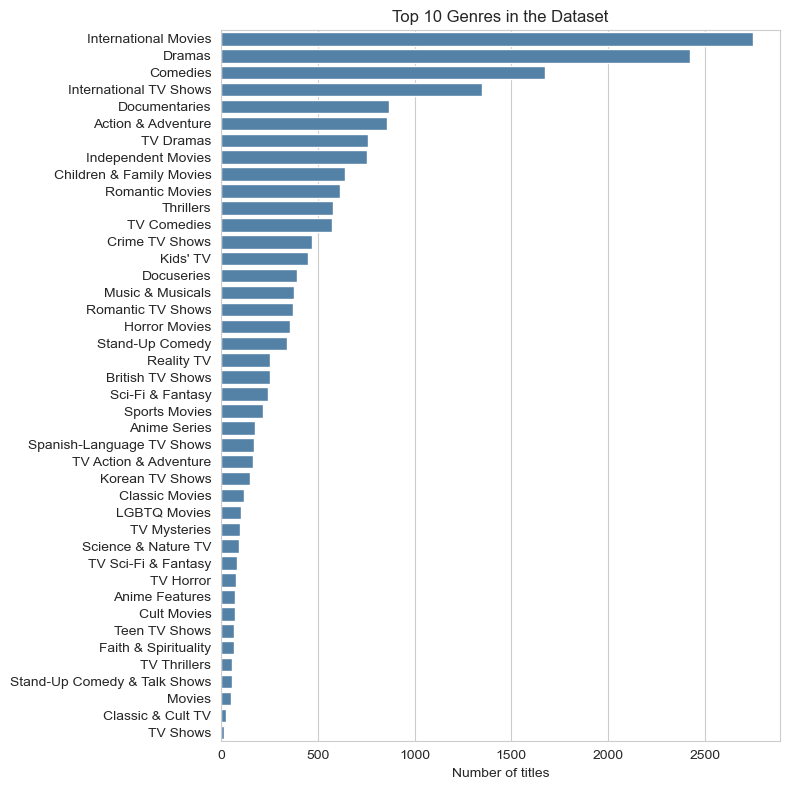

In [30]:
# One title can have several genres separated by commas -> split them, then count
genre_counts = data["listed_in"].str.split(", ").explode().value_counts()

plt.figure(figsize=(8, 8))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color="steelblue")
plt.title(" Genres in the Dataset")
plt.xlabel("Number of titles")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [8]:
def make_tokens(text):
    # Turn 'Sci-Fi & Fantasy, Thrillers' into 'scififantasy thrillers'
    if text == "":
        return ""
    tokens = []
    for item in text.split(","):              # 1. split the comma-separated list
        item = item.lower()                   # 2. lowercase
        item = re.sub(r"[\W_]+", "", item)    # 3. remove spaces and symbols
        tokens.append(item)
    return " ".join(tokens)                   # 4. join the pieces with a space


# Test the function on a few examples
print(make_tokens("Sci-Fi & Fantasy, Thrillers"))
print(make_tokens("Raúl Campos, Jan Suter"))
print(make_tokens("Kids' TV, TV Comedies"))
print(make_tokens("United States, India"))

scififantasy thrillers
raúlcampos jansuter
kidstv tvcomedies
unitedstates india


The function works. Now we apply it to every feature column.

In [9]:
data["genre_tokens"]    = data["listed_in"].apply(make_tokens)
data["director_tokens"] = data["director"].apply(make_tokens)
data["country_tokens"]  = data["country"].apply(make_tokens)
data["type_tokens"]     = data["type"].apply(make_tokens)
data["rating_tokens"]   = data["rating"].apply(make_tokens)

data[["title", "genre_tokens", "director_tokens", "country_tokens"]].head()

,title,genre_tokens,director_tokens,country_tokens
0,Dick Johnson Is Dead,documentaries,kirstenjohnson,unitedstates
1,Ganglands,crimetvshows internationaltvshows tvactionadve...,julienleclercq,france
2,Midnight Mass,tvdramas tvhorror tvmysteries,mikeflanagan,unitedstates
3,Confessions of an Invisible Girl,childrenfamilymovies comedies,brunogarotti,brazil
4,Sankofa,dramas independentmovies internationalmovies,hailegerima,unitedstates


### Combine everything into one "soup" of words

We glue all the features of a title into one text called the **soup**.

**Weighting idea:** genre is the best clue about what someone will enjoy, so we put the **genre twice**. That makes it count more than a shared country or rating.

In [10]:
data["soup"] = (
    data["genre_tokens"] + " " + data["genre_tokens"] + " "   # genre twice = double importance
    + data["director_tokens"] + " "
    + data["country_tokens"] + " "
    + data["type_tokens"] + " "
    + data["rating_tokens"]
)

# Look at the soup of one title
example = data[data["title"] == "Stranger Things"].iloc[0]
print("Title:", example["title"])
print("Soup :", example["soup"])

Title: Stranger Things
Soup : tvhorror tvmysteries tvscififantasy tvhorror tvmysteries tvscififantasy  unitedstates tvshow tv14


---
# Step 3 – Calculate Content Similarity


In [11]:
# token_pattern=r"\S+" means: every chunk of text between spaces is one word
tfidf = TfidfVectorizer(token_pattern=r"\S+")
tfidf_matrix = tfidf.fit_transform(data["soup"])

print("Matrix shape (titles x unique words):", tfidf_matrix.shape)

Matrix shape (titles x unique words): (8784, 5128)


Let us see the weights in action. A very common genre should have a **low** weight and a rare director a **high** one:

In [12]:
weights = pd.Series(tfidf.idf_, index=tfidf.get_feature_names_out())

print("Weight of some words (higher = rarer = more useful):")
weights[["internationalmovies", "dramas", "comedies", "rajivchilaka"]].round(2)

Weight of some words (higher = rarer = more useful):


internationalmovies    2.16
dramas                 2.29
comedies               2.66
rajivchilaka           6.90
dtype: float64

Now a tiny experiment: the similarity between the **first 5 titles** of the dataset. The diagonal is always `1.0` because a title is 100% similar to itself.

In [13]:
small = cosine_similarity(tfidf_matrix[:5])
first_five = data["title"][:5]

pd.DataFrame(small, index=first_five, columns=first_five).round(2)

title,Dick Johnson Is Dead,Ganglands,Midnight Mass,Confessions of an Invisible Girl,Sankofa
title,,,,,
Dick Johnson Is Dead,1.00,0.00,0.02,0.01,0.03
Ganglands,0.00,1.00,0.03,0.00,0.02
Midnight Mass,0.02,0.03,1.00,0.00,0.03
Confessions of an Invisible Girl,0.01,0.00,0.00,1.00,0.01
Sankofa,0.03,0.02,0.03,0.01,1.00


### A note on memory 💾

Our dataset has 8,784 titles. Comparing **every title with every other title** at once would create 8,784 × 8,784 ≈ **77 million numbers** (about 600 MB) and could crash a normal laptop.

Instead, we calculate similarity **only for the title the user asks about**. It is instant and light.

In [14]:
def similarity_scores(index):
    # Similarity of ONE title against ALL titles (returns a list of 8,784 numbers)
    return cosine_similarity(tfidf_matrix[index], tfidf_matrix).flatten()

---
# Generate Recommendations

Now we build the function that does the whole job. For a given title it will:

1. Find the title in the data (and suggest fixes if you made a typo).
2. Calculate its similarity with every other title.
3. Sort from most similar to least similar.
4. Skip the title itself and return the top `n`.

In [15]:
def recommend(title, n=5, show=True, content_type=None):
    key = title.lower().strip()

    # 1. Find the title (optionally only 'Movie' or only 'TV Show')
    matches = data[data["title_key"] == key]
    if content_type:
        matches = matches[matches["type"] == content_type]

    # Handle titles that do not exist (typos, wrong name)
    if matches.empty:
        suggestions = get_close_matches(key, data["title_key"].unique(), n=3, cutoff=0.5)
        print(f"'{title}' was not found. Did you mean: {suggestions} ?")
        return None

    idx = matches.index[0]

    # 2. Similarity with every title, 3. sorted from best to worst
    scores = similarity_scores(idx)
    best_first = np.argsort(-scores, kind="stable")

    # 4. Remove the title itself and keep the top n
    top = [i for i in best_first if i != idx][:n]

    result = data.loc[top, ["title", "type", "listed_in", "country"]].copy()
    result["similarity"] = scores[top].round(3)

    if show:
        me = data.loc[idx]
        print(f"🎬 Because you watched: {me['title']}  ({me['type']} | {me['listed_in']})")
        print()
    return result.reset_index(drop=True)

### Let us try it on selected titles

**Example 1 – A TV series: *Stranger Things***

In [16]:
recommend("Stranger Things")

🎬 Because you watched: Stranger Things  (TV Show | TV Horror, TV Mysteries, TV Sci-Fi & Fantasy)



,title,type,listed_in,country,similarity
0,Chilling Adventures of Sabrina,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",United States,1.000
1,Nightflyers,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",United States,0.988
2,Helix,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",United States,0.988
3,The Originals,TV Show,"TV Dramas, TV Horror, TV Mysteries",United States,0.758
4,Anjaan: Special Crimes Unit,TV Show,"International TV Shows, TV Horror, TV Mysteries",India,0.757


**Example 2 – A drama series: *The Crown***

In [17]:
recommend("The Crown")

🎬 Because you watched: The Crown  (TV Show | British TV Shows, International TV Shows, TV Dramas)



,title,type,listed_in,country,similarity
0,Behind Her Eyes,TV Show,"British TV Shows, International TV Shows, TV D...",United Kingdom,1.0
1,Black Mirror,TV Show,"British TV Shows, International TV Shows, TV D...",United Kingdom,1.0
2,Traitors,TV Show,"British TV Shows, International TV Shows, TV D...",United Kingdom,1.0
3,Black Earth Rising,TV Show,"British TV Shows, International TV Shows, TV D...",United Kingdom,1.0
4,Requiem,TV Show,"British TV Shows, International TV Shows, TV D...",United Kingdom,1.0


> 💡 **Why do several results show `1.0`?**
> A score of `1.0` means the titles have **identical information in our columns** (same genres, country, type and rating). It does *not* mean they are the same show. When many titles tie, the order among them is decided by their position in the dataset. A plot-description column would help break these ties (see the limitations in Step 5).

**Example 3 – A Bollywood movie: *3 Idiots***

In [18]:
recommend("3 Idiots")

🎬 Because you watched: 3 Idiots  (Movie | Comedies, Dramas, International Movies)



,title,type,listed_in,country,similarity
0,PK,Movie,"Comedies, Dramas, International Movies",India,0.937
1,Sanju,Movie,"Dramas, International Movies",India,0.850
2,Haapus,Movie,"Comedies, Dramas, International Movies",India,0.660
3,Mubarakan,Movie,"Comedies, Dramas, International Movies",India,0.572
4,Stuck Apart,Movie,"Comedies, Dramas, International Movies",Turkey,0.528


**Example 4 – A kids' movie: *Kung Fu Panda***

In [19]:
recommend("Kung Fu Panda")

🎬 Because you watched: Kung Fu Panda  (Movie | Children & Family Movies, Comedies)



,title,type,listed_in,country,similarity
0,The Little Prince,Movie,Children & Family Movies,France,0.701
1,Captain Underpants Epic Choice-o-Rama,Movie,"Children & Family Movies, Comedies",United States,0.510
2,The Spooky Tale of Captain Underpants Hack-a-ween,Movie,"Children & Family Movies, Comedies",United States,0.510
3,Spy Kids: All the Time in the World,Movie,"Children & Family Movies, Comedies",United States,0.493
4,We Can Be Heroes,Movie,"Children & Family Movies, Comedies",United States,0.493


**Example 5 – An anime: *Naruto***

In [20]:
recommend("Naruto")

🎬 Because you watched: Naruto  (TV Show | Anime Series, International TV Shows)



,title,type,listed_in,country,similarity
0,Yowamushi Pedal,TV Show,"Anime Series, International TV Shows",Japan,0.804
1,EDENS ZERO,TV Show,"Anime Series, International TV Shows",Japan,0.804
2,SHAMAN KING,TV Show,"Anime Series, International TV Shows",Japan,0.804
3,Hunter X Hunter (2011),TV Show,"Anime Series, International TV Shows",Japan,0.804
4,The Seven Deadly Sins,TV Show,"Anime Series, International TV Shows",Japan,0.804


### What if the user makes a typo?

Our function does not crash. It suggests the closest titles instead.

In [21]:
recommend("stranger thing")

'stranger thing' was not found. Did you mean: ['stranger things', 'beyond stranger things', 'stranger'] ?


### Same name, two versions?

Some names exist as both a movie and a TV show (for example *Death Note*). Use `content_type` to choose:

In [22]:
recommend("Death Note", content_type="TV Show")

🎬 Because you watched: DEATH NOTE  (TV Show | Anime Series, Crime TV Shows, International TV Shows)



,title,type,listed_in,country,similarity
0,Ghost in the Shell: SAC_2045,TV Show,"Anime Series, Crime TV Shows, International TV...",Japan,1.000
1,Akame ga Kill!,TV Show,"Anime Series, Crime TV Shows, International TV...",Japan,1.000
2,One-Punch Man,TV Show,"Anime Series, Crime TV Shows, International TV...",Japan,1.000
3,Durarara!!,TV Show,"Anime Series, Crime TV Shows, International TV...",Japan,0.978
4,B: The Beginning,TV Show,"Anime Series, Crime TV Shows, International TV...",Japan,0.978


### Visualising the result

A bar chart makes it easy to see **how strong** each recommendation is.

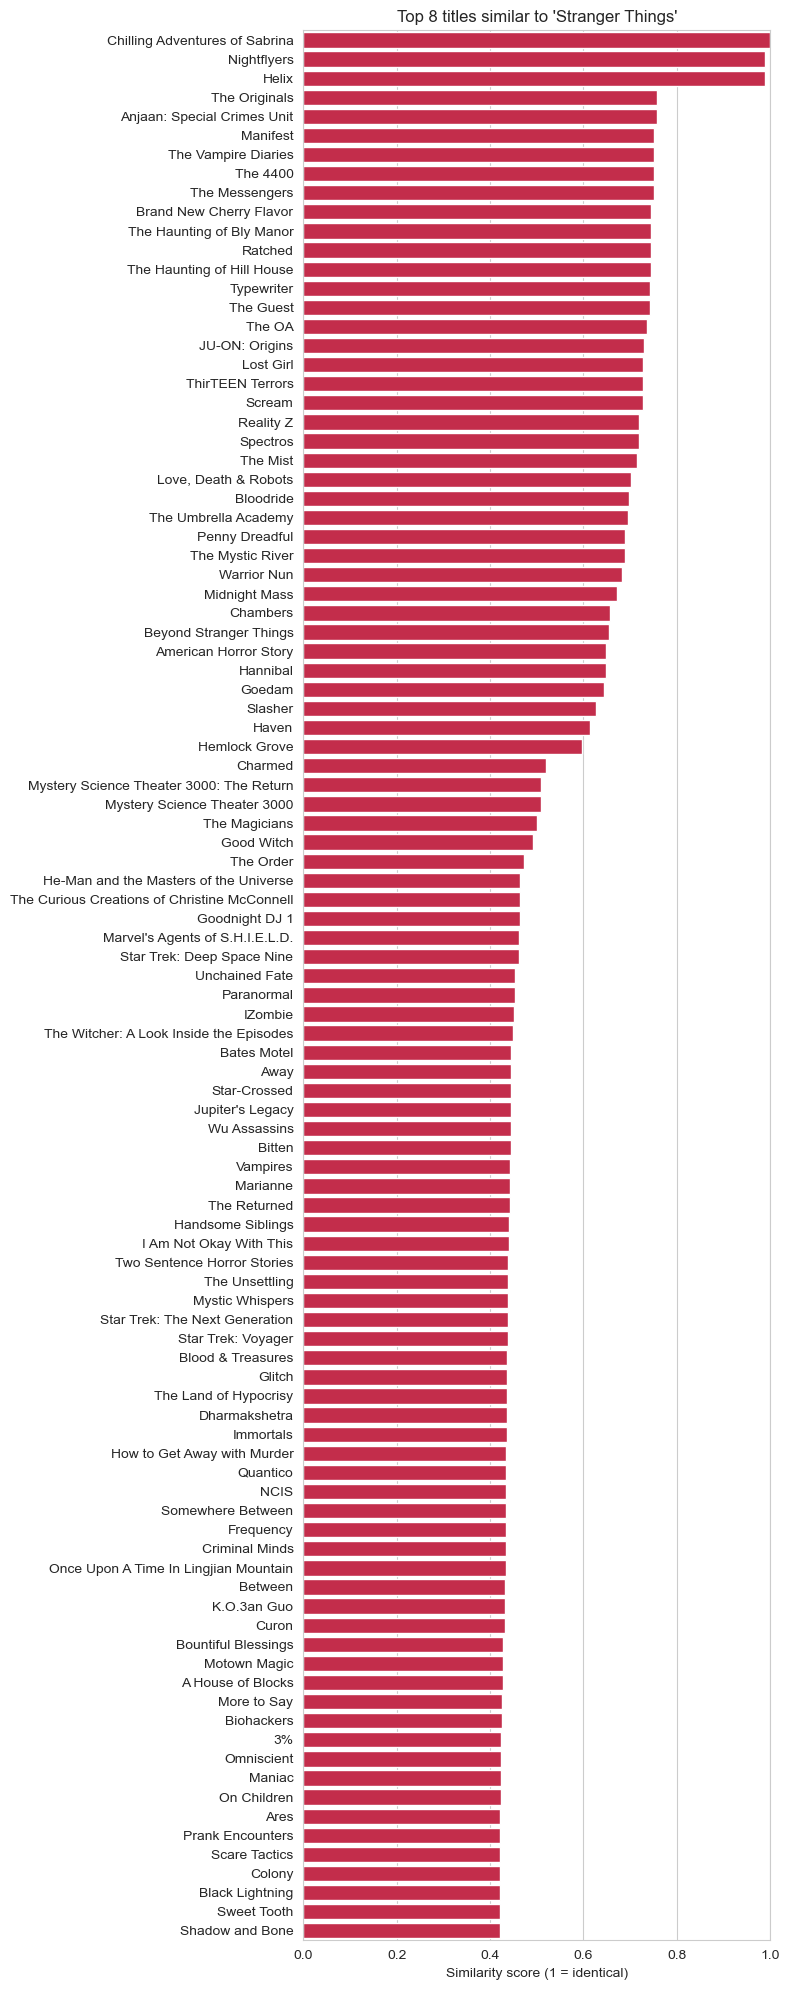

In [33]:
recs = recommend("Stranger Things", n=100, show=False)

plt.figure(figsize=(8, 20))
sns.barplot(data=recs, x="similarity", y="title", color="crimson")
plt.title("Top 100 titles similar to 'Stranger Things'")
plt.xlabel("Similarity score (1 = identical)")
plt.ylabel("")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [38]:
my_title = "Nightflyers"        # <- type any title from the dataset here
how_many = 5               # <- how many recommendations you want

recommend(my_title, n=how_many)

🎬 Because you watched: Nightflyers  (TV Show | TV Horror, TV Mysteries, TV Sci-Fi & Fantasy)



,title,type,listed_in,country,similarity
0,Helix,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",United States,1.000
1,Chilling Adventures of Sabrina,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",United States,0.988
2,Stranger Things,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",United States,0.988
3,Brand New Cherry Flavor,TV Show,"TV Dramas, TV Horror, TV Mysteries",United States,0.757
4,The Haunting of Bly Manor,TV Show,"TV Dramas, TV Horror, TV Mysteries",United States,0.757


---
# SEvaluate Recommendation Quality

Reading a few results (like we just did) is a good first check, but we also want **numbers**.

Real streaming services measure success with user behaviour (clicks, watch time, ratings). **Our dataset has none of that**, so we use an *offline evaluation*: we test many titles at once and check whether the recommendations make sense.

## Our 4 metrics

| Metric | Question it answers | Better is |
|--------|--------------------|-----------|
| **Genre Precision@5** | Out of 5 recommendations, how many share at least one genre with the original title? | Higher |
| **Genre Overlap (Jaccard)** | How much do the genre lists overlap? (0 = nothing, 1 = identical) | Higher |
| **Same-Type Rate** | Do movies get movie recommendations and TV shows get TV recommendations? | Higher |
| **Variety** | Out of all recommendation slots, how many were *different* titles? Low variety means the system keeps suggesting the same few titles. | Higher |

## The models we compare

| Model | Description |
|-------|-------------|
| **Random** | Picks 5 random titles. Any real model **must beat this**. |
| **Genres only** | Uses only the genre column. |
| **All features (equal)** | Genre, director, country, type and rating, all with the same weight. |
| **Final model** | Same as above, but genre counted twice (the model we built). |

We test on **500 randomly chosen titles**. The random seed is fixed, so you get the same numbers every time.

In [25]:
# ---------- Prepare the 4 models ----------
def build_matrix(text_column):
    vec = TfidfVectorizer(token_pattern=r"\S+")
    return vec.fit_transform(text_column)

all_equal_soup = (data["genre_tokens"] + " " + data["director_tokens"] + " " +
                  data["country_tokens"] + " " + data["type_tokens"] + " " +
                  data["rating_tokens"])

matrices = {
    "Genres only":            build_matrix(data["genre_tokens"]),
    "All features (equal)":   build_matrix(all_equal_soup),
    "Final model (genre x2)": tfidf_matrix,            # the one we already built
}

# ---------- Helpers ----------
rng = np.random.default_rng(42)                                   # fixed seed = repeatable results
sample = rng.choice(len(data), size=500, replace=False)           # 500 random titles to test

genre_sets = data["listed_in"].apply(lambda g: set(g.split(", "))).tolist()
types = data["type"].values


def top_n_model(matrix, idx, n=5):
    scores = cosine_similarity(matrix[idx], matrix).flatten()
    best_first = np.argsort(-scores, kind="stable")
    return [i for i in best_first if i != idx][:n]


def top_n_random(idx, n=5):
    picks = rng.choice(len(data), size=n + 1, replace=False)
    return [i for i in picks if i != idx][:n]


def score_model(get_recs, n=5):
    precision, overlap, same_type, all_recs = [], [], [], []

    for idx in sample:
        recs = get_recs(idx)
        my_genres = genre_sets[idx]

        # share at least one genre?
        precision.append(np.mean([len(my_genres & genre_sets[r]) > 0 for r in recs]))
        # how much do the genre lists overlap?
        overlap.append(np.mean([len(my_genres & genre_sets[r]) / len(my_genres | genre_sets[r]) for r in recs]))
        # same type (Movie / TV Show)?
        same_type.append(np.mean([types[r] == types[idx] for r in recs]))

        all_recs.extend(recs)

    return {
        "Genre Precision@5":   np.mean(precision),
        "Genre Overlap":       np.mean(overlap),
        "Same-Type Rate":      np.mean(same_type),
        "Variety":             len(set(all_recs)) / len(all_recs),
    }

In [26]:
results = {"Random (baseline)": score_model(top_n_random)}

for name, matrix in matrices.items():
    results[name] = score_model(lambda idx: top_n_model(matrix, idx))

results_table = pd.DataFrame(results).T.round(3)
results_table

,Genre Precision@5,Genre Overlap,Same-Type Rate,Variety
Random (baseline),0.238,0.089,0.594,0.876
Genres only,1.000,0.986,1.000,0.312
All features (equal),0.912,0.717,0.952,0.585
Final model (genre x2),0.995,0.912,0.999,0.587


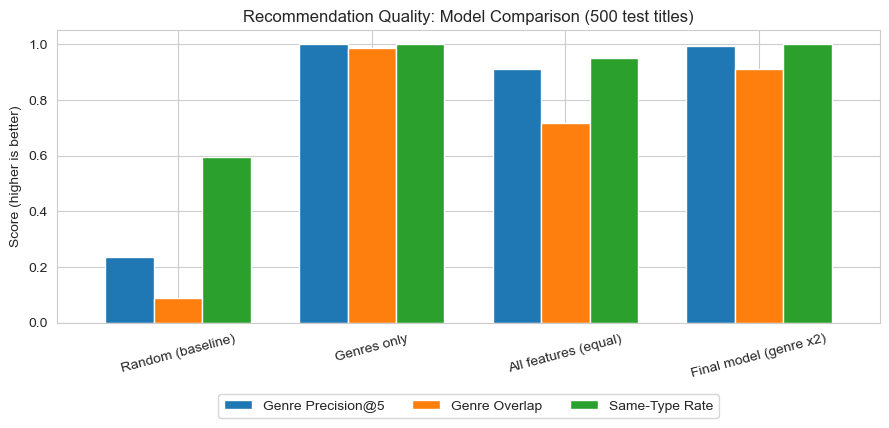

In [27]:
# Chart: compare the models on the three "relevance" metrics
results_table[["Genre Precision@5", "Genre Overlap", "Same-Type Rate"]].plot(
    kind="bar", figsize=(9, 4.5), width=0.75
)
plt.title("Recommendation Quality: Model Comparison (500 test titles)")
plt.ylabel("Score (higher is better)")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3)   # legend below the chart
plt.tight_layout()
plt.show()

## How to read these results

Our test uses 500 random titles, and the random seed is fixed, so you will get the same numbers.

- **Random baseline:** only about **24%** of random picks share a genre with the original title. Every real model must beat this, and all three do by a wide margin.
- **Genres only:** scores a perfect 100%, but that is expected because genre is the only thing it looks at (and the thing we measure). Its **variety is just 31%**, so it keeps suggesting the same titles again and again, since thousands of titles share the same genre combination.
- **All features (equal weight):** variety improves to about 59%, but relevance drops (precision 91%, overlap 72%) because director and country can pull in titles from a different genre.
- **Final model (genre x2):** the best balance. It keeps **99.5% genre precision**, **91% genre overlap** and **99.9% same-type rate**, while its **variety (59%) is almost double** that of the genres-only model.

**Conclusion:** giving genre double weight keeps the recommendations relevant while still using director, country and rating to add variety. That is why we chose it as our final model.

## Honest limitations

- **Genre metrics are a little optimistic.** Genre is also an *input* of the model, so it is not surprising that recommendations share genres. It is a sensible sanity check, not the final proof.
- **The real test is user behaviour.** With ratings or watch history we could measure hit-rate and check if people truly watch what we recommend.
- **No plot descriptions.** This dataset has no synopsis column. With one, we could add TF-IDF over the story text and catch themes like "space", "prison" or "revenge".
- **Many ties.** Lots of titles share the exact same genres, country and rating, so they get the same score. A plot description would separate them.
- **Some data looks noisy.** For example, *Squid Game* is listed with country *Pakistan*. Wrong values like this reduce the value of the country feature.

---
# Save the Recommendations

We save the recommendations of our selected titles to a CSV file. You can attach it to your submission.

In [36]:
selected_titles = ["Stranger Things", "The Crown", "3 Idiots", "Kung Fu Panda", "Naruto"]

saved = []
for t in selected_titles:
    r = recommend(t, n=5, show=False)
    r.insert(0, "because_you_watched", t)
    saved.append(r)

final_table = pd.concat(saved, ignore_index=True)
final_table.to_csv("recommendations_output.csv", index=False)

print("Saved", len(final_table), "recommendations to recommendations_output.csv")
final_table.head(10)

Saved 25 recommendations to recommendations_output.csv


,because_you_watched,title,type,listed_in,country,similarity
0,Stranger Things,Chilling Adventures of Sabrina,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",United States,1.000
1,Stranger Things,Nightflyers,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",United States,0.988
2,Stranger Things,Helix,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",United States,0.988
3,Stranger Things,The Originals,TV Show,"TV Dramas, TV Horror, TV Mysteries",United States,0.758
4,Stranger Things,Anjaan: Special Crimes Unit,TV Show,"International TV Shows, TV Horror, TV Mysteries",India,0.757
5,The Crown,Behind Her Eyes,TV Show,"British TV Shows, International TV Shows, TV D...",United Kingdom,1.000
6,The Crown,Black Mirror,TV Show,"British TV Shows, International TV Shows, TV D...",United Kingdom,1.000
7,The Crown,Traitors,TV Show,"British TV Shows, International TV Shows, TV D...",United Kingdom,1.000
8,The Crown,Black Earth Rising,TV Show,"British TV Shows, International TV Shows, TV D...",United Kingdom,1.000
9,The Crown,Requiem,TV Show,"British TV Shows, International TV Shows, TV D...",United Kingdom,1.000


---
# ✅ Conclusion

**What we built:** a content-based recommendation system for 8,784 Netflix titles.

**Steps completed**

1. **Extracted features**: genre, director, country, type and rating.
2. **Preprocessed text**: removed the fake `"Not Given"` values, lowercased, and merged names into single tokens.
3. **Calculated similarity**: TF-IDF numbers plus cosine similarity, computed on demand to save memory.
4. **Generated recommendations**: a reusable `recommend()` function with typo suggestions.
5. **Evaluated quality**: compared against a random baseline and two alternative models.

**Ideas to improve further**

- Add plot descriptions or keywords (NLP on real text).
- Fine-tune the weights (for example genre × 3, or director × 0.5).
- Combine with user ratings for a hybrid system.
